# CNN com transformada Wavelet no Pipeline

## Wavelet Daubechies 4

Agora vamos variar a wavelet mãe usada para verificar como irá se comportar o modelo.

A wavelet mãe escolhida foi a Daubechies, pois é uma função muito popular, assimétrica e com diferentes ordenss de suavidade. Excelente para compressão e limpeza de ruído em sinais gerais.

A função wavelet Daubechies 4 tem esse formato:

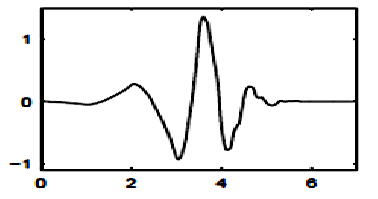


## Implementação da Camada Wavelet Daubechies 4

Abaixo código da camada db4 implementada.

### Com Wavelet Treinável e Stride = 2

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np

class WaveletPoolingDaubechies(nn.Module):
    def __init__(self, in_channels):
        super(WaveletPoolingDaubechies, self).__init__()
        self.in_channels = in_channels
        
        # 1. Obter filtros da Wavelet db4
        wavelet = pywt.Wavelet('db4')
        dec_lo = np.array(wavelet.dec_lo)
        dec_hi = np.array(wavelet.dec_hi)

        # 2. Criar filtros 2D (LL, LH, HL, HH)
        ll = np.outer(dec_lo, dec_lo)
        lh = np.outer(dec_lo, dec_hi)
        hl = np.outer(dec_hi, dec_lo)
        hh = np.outer(dec_hi, dec_hi)

        # Stack e expansão para o formato [4, 1, H, W]
        filters = np.stack([ll, lh, hl, hh], axis=0)
        filters = torch.tensor(filters, dtype=torch.float32).unsqueeze(1)
        
        # O formato [4 * in_channels, 1, H, W] permite que cada canal 
        # aprenda sua própria variação da wavelet se quisermos.
        initial_weights = filters.repeat(in_channels, 1, 1, 1)
        
        # Agora o requires_grad é True por padrão ao usar nn.Parameter
        self.weight = nn.Parameter(initial_weights, requires_grad=True)
        
        self.padding = filters.shape[-1] // 2

    def forward(self, x):
        # Aplica DWT: reduz resolução e quadruplica canais (C -> 4C)
        return F.conv2d(x, self.weight, stride=2, padding=self.padding, groups=self.in_channels)

## Convolutional Block Attention Module (CBAM)

O Convolutional Block Attention Module é um módulo que:

- refina o mapa de features aplicando atenção em duas dimensões:
    - CANAL → “O QUE é importante”
    - ESPACIAL → “ONDE é importante”

## Channel Attention

In [3]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.size()

        avg_pool = torch.mean(x, dim=(2,3))        # [B, C]
        max_pool, _ = torch.max(x.view(B, C, -1), dim=2)

        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)

        out = avg_out + max_out
        out = self.sigmoid(out).view(B, C, 1, 1)

        return x * out

## Spatial Attention

In [4]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)

        concat = torch.cat([avg, maxv], dim=1)
        att = self.sigmoid(self.conv(concat))

        return x * att

## CBAM completo

In [5]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

## Etapa de CLASSIFICAÇÃO + DATALOADER

- Classificando as imagnes do Dataset mini-mias

- Carregando dataset para CNN aplicando Data Augmentation (aumento de dados)
    - Efetuado ainda mais variações nas imagens (data augmentation) para conseguir aumentar o dataset.

In [6]:
import os
import random
import shutil
import re
from PyPDF2 import PdfReader

import cv2
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ================================
# CONFIG
# ================================
PASTA_MIAs = "dataset-mias"
OUTPUT_DATASET = "dataset"
PDF_PATH = os.path.join(PASTA_MIAs, "00README.pdf")

# ================================
# 1. PEGAR TODAS AS IMAGENS (GARANTE 322)
# ================================
todas_imagens = sorted([
    f for f in os.listdir(PASTA_MIAs)
    if f.endswith(".pgm")
])

print(f"Total de imagens encontradas: {len(todas_imagens)}")

# ================================
# 2. LER PDF E CRIAR MAPA DE CLASSES
# ================================
reader = PdfReader(PDF_PATH)

texto_total = ""
for pagina in reader.pages:
    txt = pagina.extract_text()
    if txt:
        texto_total += txt + "\n"

linhas = texto_total.split("\n")

mapa_classes = {}

for linha in linhas:
    linha = linha.strip()

    if linha.startswith("mdb"):
        partes = linha.split()

        if len(partes) >= 3:
            nome = partes[0] + ".pgm"
            classe = partes[2]
            mapa_classes[nome] = classe

# ================================
# 3. CLASSIFICAR SEM PERDER IMAGENS
# ================================
com_nodulo = []
sem_nodulo = []

for nome in todas_imagens:
    classe = mapa_classes.get(nome, None)

    # Se não encontrou no PDF → assume como anormal (mais seguro)
    if classe is None:
        com_nodulo.append(nome)
    elif classe == "NORM":
        sem_nodulo.append(nome)
    else:
        com_nodulo.append(nome)

# ================================
# 4. VALIDAÇÃO (AGORA NÃO FALHA)
# ================================
total = len(com_nodulo) + len(sem_nodulo)

print("\n===== VALIDAÇÃO =====")
print(f"Com nódulo: {len(com_nodulo)}")
print(f"Sem nódulo: {len(sem_nodulo)}")
print(f"TOTAL: {total}")

assert total == len(todas_imagens), "Erro: perda de imagens!"

# ================================
# 5. LIMPAR DATASET ANTIGO
# ================================
shutil.rmtree(OUTPUT_DATASET, ignore_errors=True)

# ================================
# 6. CRIAR PASTAS
# ================================
os.makedirs("dataset/train/com_nodulo", exist_ok=True)
os.makedirs("dataset/train/sem_nodulo", exist_ok=True)
os.makedirs("dataset/test/com_nodulo", exist_ok=True)
os.makedirs("dataset/test/sem_nodulo", exist_ok=True)

# ================================
# 7. SPLIT
# ================================
def dividir(lista, pasta_train, pasta_test):
    random.shuffle(lista)
    corte = int(0.7 * len(lista))

    train = lista[:corte]
    test = lista[corte:]

    for nome in train:
        shutil.copy2(
            os.path.join(PASTA_MIAs, nome),
            os.path.join(pasta_train, nome)
        )

    for nome in test:
        shutil.copy2(
            os.path.join(PASTA_MIAs, nome),
            os.path.join(pasta_test, nome)
        )

    return len(train), len(test)

train_c, test_c = dividir(com_nodulo, "dataset/train/com_nodulo", "dataset/test/com_nodulo")
train_s, test_s = dividir(sem_nodulo, "dataset/train/sem_nodulo", "dataset/test/sem_nodulo")

print("\n===== SPLIT =====")
print(f"Train com nódulo: {train_c}")
print(f"Test com nódulo: {test_c}")
print(f"Train sem nódulo: {train_s}")
print(f"Test sem nódulo: {test_s}")

# ================================
# 8. CLAHE
# ================================
class ApplyCLAHE:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __call__(self, img):
        img_np = np.array(img)

        if img_np.ndim == 3:
            img_np = img_np[..., 0]

        img_np = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_clahe = self.clahe.apply(img_np)

        return Image.fromarray(img_clahe)

# ================================
# 9. TRANSFORMS
# ================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ================================
# 10. DATASET + DATALOADER
# ================================
train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
test_dataset = datasets.ImageFolder("dataset/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print("\nPIPELINE COMPLETO PRONTO!")

Total de imagens encontradas: 322

===== VALIDAÇÃO =====
Com nódulo: 117
Sem nódulo: 205
TOTAL: 322

===== SPLIT =====
Train com nódulo: 81
Test com nódulo: 36
Train sem nódulo: 143
Test sem nódulo: 62

PIPELINE COMPLETO PRONTO!


## Modelo com Wavelet (db4) + CNN + Attention CBAM

<img src="img/waveletCNN-modelo11.png" width="500" title="Dica de ferramenta">

In [7]:
"""
MODELO COM A WAVELET SUBSTITUINDO O MAXPOOLING, CONVOLUÇÕES E CBAM
"""
class WaveletCNN_DB4(nn.Module):
    def __init__(self):
        super().__init__()

        self.wavelet_input = WaveletPoolingDaubechies(in_channels=1)

        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            CBAM(32), 
            WaveletPoolingDaubechies(in_channels=32),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            CBAM(64), 
            WaveletPoolingDaubechies(in_channels=64),

            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            CBAM(128), 
            WaveletPoolingDaubechies(in_channels=128),

        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.wavelet_input(x)
        x = self.features(x)
        x = self.classifier(x)
        return x

#### Antes do treino:

Conta quantas amostras existem de cada classe, é importante isso quando temos um dataset desbalanceado.

In [9]:
from collections import Counter

labels_list = [label for _, label in train_dataset.samples]

class_counts_dict = Counter(labels_list)

print("Distribuição das classes:", class_counts_dict)

num_normal = class_counts_dict[0]
num_cancer = class_counts_dict[1]

Distribuição das classes: Counter({1: 143, 0: 81})


## Treinando o modelo

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Modelo
model = WaveletCNN_DB4()

# 2. Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Loss com balanceamento
class_counts = [num_normal, num_cancer]

weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# 4. Otimizador
"""
    "lr" = learning rate -> refere-se ao quanto o modelo irá mudar os pesos a cada erro que tiver
"""
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# 5. Scheduler 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    corretos_treino = 0
    total_treino = 0
    
    for imagens, labels in train_loader:
        imagens, labels = imagens.to(device), labels.to(device)
        
        outputs = model(imagens)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_treino += labels.size(0)
        corretos_treino += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * corretos_treino / total_treino
    
    print(f"Época [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc Treino: {epoch_acc:.2f}%")

    scheduler.step(epoch_loss)

    # Validação
    if (epoch + 1) % 5 == 0:
        model.eval()
        corretos_teste = 0
        total_teste = 0

        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                _, pred = torch.max(out, 1)

                total_teste += lbls.size(0)
                corretos_teste += (pred == lbls).sum().item()

        print(f">>> Acurácia de Teste: {100 * corretos_teste / total_teste:.2f}%")

Época [1/50] - Loss: 0.6959 - Acc Treino: 46.88%
Época [2/50] - Loss: 0.6917 - Acc Treino: 55.36%
Época [3/50] - Loss: 0.6943 - Acc Treino: 51.34%
Época [4/50] - Loss: 0.6927 - Acc Treino: 59.38%
Época [5/50] - Loss: 0.6919 - Acc Treino: 50.00%
>>> Acurácia de Teste: 48.98%
Época [6/50] - Loss: 0.6913 - Acc Treino: 53.57%
Época [7/50] - Loss: 0.6921 - Acc Treino: 50.45%
Época [8/50] - Loss: 0.6905 - Acc Treino: 52.23%
Época [9/50] - Loss: 0.6828 - Acc Treino: 58.93%
Época [10/50] - Loss: 0.6956 - Acc Treino: 50.45%
>>> Acurácia de Teste: 54.08%
Época [11/50] - Loss: 0.6896 - Acc Treino: 57.14%
Época [12/50] - Loss: 0.6906 - Acc Treino: 53.57%
Época [13/50] - Loss: 0.6909 - Acc Treino: 53.57%
Época [14/50] - Loss: 0.6883 - Acc Treino: 54.46%
Época [15/50] - Loss: 0.6871 - Acc Treino: 54.46%
>>> Acurácia de Teste: 46.94%
Época [16/50] - Loss: 0.6885 - Acc Treino: 57.14%
Época [17/50] - Loss: 0.6926 - Acc Treino: 51.34%
Época [18/50] - Loss: 0.6896 - Acc Treino: 52.23%
Época [19/50] - Los

## Testando o modelo

In [11]:
model.eval()
corretos = 0
total = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for imagens, labels in test_loader:
        
        imagens, labels = imagens.to(device), labels.to(device)

        outputs = model(imagens)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        corretos += (predicted == labels).sum().item()

print(f"Acurácia: {100 * corretos / total:.2f}%")

Acurácia: 46.94%
